# Attention vs. functional connectivity (FC) -- new `timepoint_patching_size=1` model

Adapted from `../../validation/fc_attention_correlation.ipynb` (which analyzed the
`old_13M` checkpoint, `timepoint_patching_size=20`, `window_size=200`) for the model
trained in `../train.py` (`timepoint_patching_size=1`, `WINDOW=32`; see `../README.md`).

**What changed vs. the original notebook, and why:**

- **Checkpoint**: loaded from a local directory (`checkpoint/`, downloaded from the
  cluster) instead of the HuggingFace Hub `vandijklab/brainlm/old_13M`.
- **`WINDOW_SIZE`**: 200 -> 32 TRs. Two independent reasons force this: (1) it must match
  the window the model was actually trained on (`num_timepoints_per_voxel=32`) --
  the model's position encoding and input distribution are specific to that window;
  (2) at `timepoint_patching_size=1`, `WINDOW_SIZE=200` would mean a `84,800`-token
  sequence -- computationally infeasible (the attention matrix alone would be tens of
  GB per layer). At `WINDOW_SIZE=32`, `seq_len = 424*32 = 13,568` (+1 CLS) -- large
  compared to `old_13M`'s `4,240`, but tractable on CPU.
- **Per-patch section dropped and replaced**: the original notebook's "windowed FC vs.
  per-patch attention" section correlated each of `old_13M`'s 10 per-20-TR-patch
  attention blocks against the FC computed on that patch's own 20 TRs. At
  `timepoint_patching_size=1`, a "patch" is a single TR, and Pearson correlation over a
  single timepoint is undefined (no variance to compute). FC needs the full window to be
  well-defined, so that section is replaced with a single, fair comparison per subject:
  FC computed on the **same fixed 32-TR window** the model actually saw, vs. attention
  **time-averaged over that same window** -- matched time span, one number per subject
  instead of 10 degenerate ones.
- Everything else (disk-based whole-recording comparison, design rationale for including
  the diagonal, etc.) is unchanged from the original.


In [1]:
import os
import csv
import glob

import h5py
import numpy as np
import matplotlib.pyplot as plt

INPUT_H5 = "../../data/input/fmri_timeseries_subset_100.h5"
ATTENTION_DIR = "outputs/attention_matrices"

FIGURES_DIR = "figures"
OUTPUTS_DIR = "outputs"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)


## Discover subjects with saved attention

Run `run_model_1tr.py` first to populate `outputs/attention_matrices/`, e.g.:

```
python run_model_1tr.py \
    --input_h5 ../../data/input/fmri_timeseries_subset_100.h5 \
    --output_dir outputs/attention_matrices \
    --coords ../../data/input/toolkit/atlases/A424_Coordinates.dat \
    --checkpoint_dir checkpoint \
    --window_size 32
```


In [2]:
attention_files = sorted(glob.glob(os.path.join(ATTENTION_DIR, "*_attention.npy")))
subject_ids_with_attention = [os.path.basename(p).replace("_attention.npy", "") for p in attention_files]

print(f"Found {len(subject_ids_with_attention)} subjects with saved last-layer attention:")
print(subject_ids_with_attention)


Found 100 subjects with saved last-layer attention:
['Sub_0000', 'Sub_0001', 'Sub_0002', 'Sub_0004', 'Sub_0005', 'Sub_0006', 'Sub_0007', 'Sub_0008', 'Sub_0009', 'Sub_0010', 'Sub_0011', 'Sub_0012', 'Sub_0013', 'Sub_0014', 'Sub_0015', 'Sub_0016', 'Sub_0017', 'Sub_0018', 'Sub_0019', 'Sub_0020', 'Sub_0021', 'Sub_0022', 'Sub_0023', 'Sub_0024', 'Sub_0025', 'Sub_0026', 'Sub_0027', 'Sub_0028', 'Sub_0029', 'Sub_0030', 'Sub_0031', 'Sub_0032', 'Sub_0033', 'Sub_0034', 'Sub_0035', 'Sub_0036', 'Sub_0037', 'Sub_0038', 'Sub_0039', 'Sub_0040', 'Sub_0041', 'Sub_0042', 'Sub_0043', 'Sub_0044', 'Sub_0045', 'Sub_0046', 'Sub_0047', 'Sub_0048', 'Sub_0049', 'Sub_0050', 'Sub_0051', 'Sub_0052', 'Sub_0053', 'Sub_0054', 'Sub_0055', 'Sub_0056', 'Sub_0057', 'Sub_0058', 'Sub_0059', 'Sub_0060', 'Sub_0061', 'Sub_0062', 'Sub_0063', 'Sub_0064', 'Sub_0065', 'Sub_0066', 'Sub_0067', 'Sub_0068', 'Sub_0069', 'Sub_0070', 'Sub_0071', 'Sub_0072', 'Sub_0073', 'Sub_0074', 'Sub_0075', 'Sub_0076', 'Sub_0077', 'Sub_0078', 'Sub_0079',

In [3]:
with h5py.File(INPUT_H5, "r") as f:
    all_ids = [s.decode("utf-8") for s in f["subject_ids"][:]]
h5_index_of = {sid: i for i, sid in enumerate(all_ids)}

missing = [sid for sid in subject_ids_with_attention if sid not in h5_index_of]
if missing:
    raise KeyError(f"Subjects with saved attention but not found in {INPUT_H5}: {missing}")


## FC computation and per-subject correlation (disk-based, whole recording)

In [4]:
def compute_fc(raw_ts):
    """Pearson correlation matrix of the raw BOLD region time series.
    raw_ts: [num_timepoints, num_regions]. Returns [num_regions, num_regions]."""
    return np.corrcoef(raw_ts.T)


In [5]:
results = []
fcs = []
attns = []
with h5py.File(INPUT_H5, "r") as f:
    for sub_id, attn_path in zip(subject_ids_with_attention, attention_files):
        raw_ts = f["parcel_ts"][h5_index_of[sub_id], :, :]
        fc = compute_fc(raw_ts)
        attn = np.load(attn_path)

        r = np.corrcoef(fc.ravel(), attn.ravel())[0, 1]

        fcs.append(fc)
        attns.append(attn)

        results.append({"subject_id": sub_id, "r_fc_attention": r})
        print(f"{sub_id}: r(FC, attention) = {r:.4f}")

r_values = np.array([res["r_fc_attention"] for res in results])
print(
    f"\n{len(results)} subjects -- r(FC, attention): mean={np.nanmean(r_values):.4f}, "
    f"median={np.nanmedian(r_values):.4f}, std={np.nanstd(r_values):.4f}, "
    f"min={np.nanmin(r_values):.4f}, max={np.nanmax(r_values):.4f}"
)


Sub_0000: r(FC, attention) = 0.2258


Sub_0001: r(FC, attention) = 0.2871


Sub_0002: r(FC, attention) = 0.1158


Sub_0004: r(FC, attention) = 0.2874


Sub_0005: r(FC, attention) = 0.1339


...

Sub_0096: r(FC, attention) = 0.2620


Sub_0097: r(FC, attention) = 0.2972


Sub_0098: r(FC, attention) = 0.2920


Sub_0099: r(FC, attention) = 0.2820
Sub_0100: r(FC, attention) = nan


Sub_0101: r(FC, attention) = 0.1772

100 subjects -- r(FC, attention): mean=0.2242, median=0.2319, std=0.0642, min=0.0512, max=0.3493


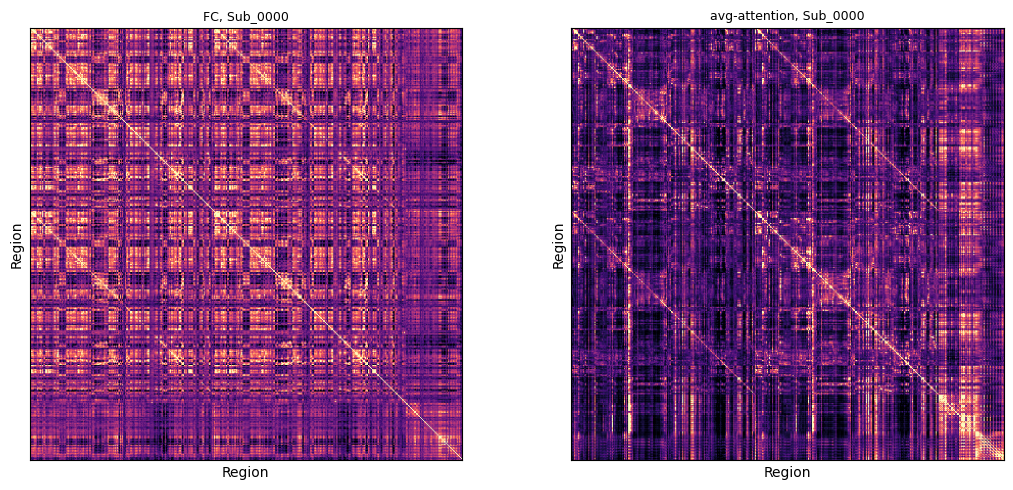

In [6]:
def show_matrix(ax, matrix, title):
    v_lo, v_hi = np.percentile(matrix, 1), np.percentile(matrix, 99)
    im = ax.imshow(matrix, cmap="magma", vmin=v_lo, vmax=v_hi)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("Region")
    ax.set_ylabel("Region")
    ax.set_title(f"{title}, {subject_ids_with_attention[0]}", fontsize=9)
    return im

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
show_matrix(axes[0], fcs[0] / np.max(fcs[0]), "FC")
show_matrix(axes[1], attns[0] / np.max(attns[0]), "avg-attention")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"{subject_ids_with_attention[0]}_FC_vs_attn.png"), dpi=130, bbox_inches="tight")
plt.show()


In [7]:
csv_path = os.path.join(OUTPUTS_DIR, "fc_attention_correlation.csv")
with open(csv_path, "w", newline="") as f_out:
    writer = csv.DictWriter(f_out, fieldnames=["subject_id", "r_fc_attention"])
    writer.writeheader()
    writer.writerows(results)
print(f"Saved per-subject correlations -> {csv_path}")


Saved per-subject correlations -> outputs/fc_attention_correlation.csv


## Distribution across subjects (disk-based, whole recording)

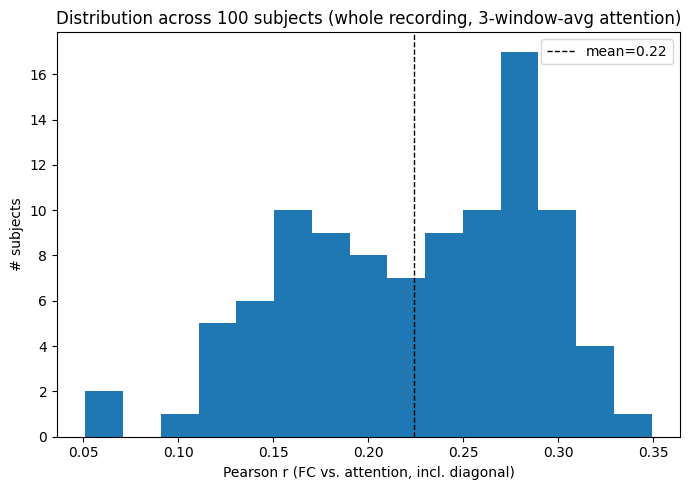

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

ax.hist(r_values, bins=15, color="tab:blue")
ax.axvline(np.nanmean(r_values), color="black", linestyle="--", linewidth=1, label=f"mean={np.nanmean(r_values):.2f}")
ax.set_xlabel("Pearson r (FC vs. attention, incl. diagonal)")
ax.set_ylabel("# subjects")
ax.set_title(f"Distribution across {len(results)} subjects (whole recording, 3-window-avg attention)")
ax.legend()

fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "fc_attention_correlation_distribution.png"), dpi=130, bbox_inches="tight")
plt.show()


## Single fixed-window (TRs 0:32) FC vs. attention -- fair, matched-timespan comparison

The comparison above has an apples-to-oranges issue: it correlates attention averaged
over **3 sliding windows** (`run_model_1tr.py`'s default) against an FC computed on the
**entire recording** (1200 TRs) -- not the same time support the attention was actually
computed on.

A fairer comparison: run a single fresh forward pass over **one fixed window, TRs
`[0, WINDOW_SIZE)`**, average that window's attention over all `num_patches=32` time
patches (i.e. over the whole window, since each patch is 1 TR), and correlate against
the FC computed on that **same 32-TR slice** of the real time series -- matched time
span, one `r` per subject.

(This replaces the original `old_13M` notebook's "windowed FC vs. per-patch attention"
section, which does not have a valid analog at `timepoint_patching_size=1` -- see the
top-of-notebook note.)


In [9]:
import sys

sys.path.insert(0, os.path.abspath("."))

import torch

from run_model_1tr import load_brainlm_model, load_spatial_coordinates

get_ipython().run_line_magic("matplotlib", "inline")

COORDS = "../../data/input/toolkit/atlases/A424_Coordinates.dat"
CHECKPOINT_DIR = "checkpoint"
WINDOW_SIZE = 32  # TRs; must match training (num_timepoints_per_voxel) -- see ../README.md

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model, config = load_brainlm_model(CHECKPOINT_DIR)
model.to(device)

spatial_coords_base = load_spatial_coordinates(COORDS).to(device)

num_regions = config.num_brain_voxels
timepoint_patching_size = config.timepoint_patching_size
num_patches = WINDOW_SIZE // timepoint_patching_size
seq_len = num_regions * num_patches
identity_noise = (torch.arange(seq_len, dtype=torch.float32) / seq_len).unsqueeze(0).to(device)

print(f"num_regions={num_regions}, num_patches={num_patches} (patch={timepoint_patching_size} TR), seq_len={seq_len}")


Device: cpu


/share/data1/mossf/miniconda3/envs/brainlm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading weights file checkpoint/pytorch_model.bin


All model checkpoint weights were used when initializing BrainLMForPretraining.



All the weights of BrainLMForPretraining were initialized from the model checkpoint at checkpoint.
If your task is similar to the task the model of the checkpoint was trained on, you can already use BrainLMForPretraining for predictions without further training.


num_regions=424, num_patches=32 (patch=1 TR), seq_len=13568


In [10]:
def robust_scale_regions(window_raw):
    """Per-region median/IQR scaling, same recipe as run_model_1tr.py's
    preprocess_subject_data, applied to a single [window_size, num_regions] window.
    Only affects the model's input -- FC below uses the raw window directly."""
    scaled = window_raw.T.copy()
    for r in range(scaled.shape[0]):
        v = scaled[r, :]
        median = np.median(v)
        q75, q25 = np.percentile(v, [75, 25])
        iqr = q75 - q25
        if iqr == 0:
            iqr = 1e-6
        scaled[r, :] = (v - median) / iqr
    return scaled


def window_attention_time_avg(window_raw):
    """Single WINDOW_SIZE-TR window -> [num_regions, num_regions] last-layer attention,
    averaged over heads (already done by the model call) and over all time patches
    (i.e. over the whole window)."""
    scaled = robust_scale_regions(window_raw)
    fmri_window = torch.tensor(scaled[None, ...], dtype=torch.float32).to(device)

    with torch.no_grad():
        outputs = model.vit(
            signal_vectors=fmri_window,
            xyz_vectors=spatial_coords_base,
            noise=identity_noise,
            output_attentions=True,
        )

    ids_restore = outputs.ids_restore.cpu().numpy()
    if not np.array_equal(ids_restore, np.broadcast_to(np.arange(seq_len), ids_restore.shape)):
        raise RuntimeError("Token order was shuffled (ids_restore != identity); refusing to reshape.")

    attn_no_cls = outputs.attentions[-1].mean(dim=(0, 1))[1:, 1:]  # heads averaged -> [seq_len, seq_len]
    attn_reshaped = attn_no_cls.view(num_regions, num_patches, num_regions, num_patches)
    return attn_reshaped.mean(dim=(1, 3)).cpu().numpy()


In [11]:
single_window_results = []
with h5py.File(INPUT_H5, "r") as f:
    for sub_id in subject_ids_with_attention:
        raw_ts = f["parcel_ts"][h5_index_of[sub_id], :, :]
        window_raw = raw_ts[:WINDOW_SIZE, :]
        if np.isnan(window_raw).any():
            raise ValueError(f"{sub_id}: NaNs in the first {WINDOW_SIZE} TRs.")

        fc_window = compute_fc(window_raw)
        attn_time_avg = window_attention_time_avg(window_raw)
        r = np.corrcoef(fc_window.ravel(), attn_time_avg.ravel())[0, 1]

        single_window_results.append({"subject_id": sub_id, "r_fc_attention": r})
        print(f"{sub_id}: r(FC[0:{WINDOW_SIZE}], attention[0:{WINDOW_SIZE}]) = {r:.4f}")

single_window_r_values = np.array([res["r_fc_attention"] for res in single_window_results])
print(
    f"\n{len(single_window_results)} subjects -- matched-window r(FC, attention): "
    f"mean={np.nanmean(single_window_r_values):.4f}, median={np.nanmedian(single_window_r_values):.4f}, "
    f"std={np.nanstd(single_window_r_values):.4f}, min={np.nanmin(single_window_r_values):.4f}, "
    f"max={np.nanmax(single_window_r_values):.4f}"
)
print(f"(disk-based, whole-recording FC vs. 3-window-avg attention gave mean={np.nanmean(r_values):.4f}, for comparison)")


Sub_0000: r(FC[0:32], attention[0:32]) = 0.1609


Sub_0001: r(FC[0:32], attention[0:32]) = 0.1303


Sub_0002: r(FC[0:32], attention[0:32]) = 0.1510


Sub_0004: r(FC[0:32], attention[0:32]) = 0.1350


Sub_0005: r(FC[0:32], attention[0:32]) = 0.0786


...

Sub_0097: r(FC[0:32], attention[0:32]) = 0.0867


Sub_0098: r(FC[0:32], attention[0:32]) = 0.0975


Sub_0099: r(FC[0:32], attention[0:32]) = 0.1801


Sub_0100: r(FC[0:32], attention[0:32]) = 0.1308


Sub_0101: r(FC[0:32], attention[0:32]) = 0.1129

100 subjects -- matched-window r(FC, attention): mean=0.1232, median=0.1305, std=0.0474, min=-0.0014, max=0.2052
(disk-based, whole-recording FC vs. 3-window-avg attention gave mean=0.2242, for comparison)


Saved matched-window per-subject correlations -> outputs/single_window_fc_attention_correlation.csv


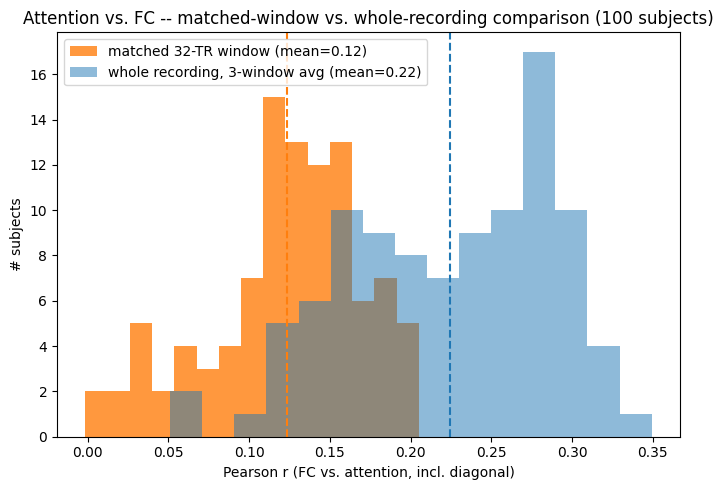

In [12]:
single_window_csv_path = os.path.join(OUTPUTS_DIR, "single_window_fc_attention_correlation.csv")
with open(single_window_csv_path, "w", newline="") as f_out:
    writer = csv.DictWriter(f_out, fieldnames=["subject_id", "r_fc_attention"])
    writer.writeheader()
    writer.writerows(single_window_results)
print(f"Saved matched-window per-subject correlations -> {single_window_csv_path}")

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.hist(single_window_r_values, bins=15, color="tab:orange", alpha=0.8,
        label=f"matched 32-TR window (mean={np.nanmean(single_window_r_values):.2f})")
ax.hist(r_values, bins=15, color="tab:blue", alpha=0.5,
        label=f"whole recording, 3-window avg (mean={np.nanmean(r_values):.2f})")
ax.axvline(np.nanmean(single_window_r_values), color="tab:orange", linestyle="--", linewidth=1.5)
ax.axvline(np.nanmean(r_values), color="tab:blue", linestyle="--", linewidth=1.5)
ax.set_xlabel("Pearson r (FC vs. attention, incl. diagonal)")
ax.set_ylabel("# subjects")
ax.set_title(f"Attention vs. FC -- matched-window vs. whole-recording comparison ({len(results)} subjects)")
ax.legend()

fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "single_window_vs_whole_recording_distribution.png"), dpi=130, bbox_inches="tight")
plt.show()
